In [2]:
DATA_START = "2021-01-01"
DATA_END = "2026-03-18"
SYMBOLS = ["510300.SS", "513100.SS", "518880.SS"]
NAMES = ["沪深300", "纳指100", "黄金"]
PERIOD = 20
REBALANCE_DAYS = 10
INITIAL_CASH = 100_000.0
ANNUAL_DAYS = 252
TOL = 1e-6


# 资产配置 v2：文章参数与整数股回测
复用公共 Account、SimBroker、Engine，策略在 allocation.py。
- 等权 1/N；风险平价按20日日对数收益标准差的倒数归一化。
- RAM = [ln(P_t)-ln(P_{t-20})]/20 ÷ std(日对数收益，20日，ddof=1)；非正RAM剔除，剩余按分值比例分配；全非正时现金100%。
- 在第0、10、20…号交易日调仓（每10个交易日），前20个观测不足以计算指标时，风险平价和RAM持有现金；等权从首日建仓。
- 不向策略提供起点以前的数据；整数股每股向下取整，先卖后买，零头现金保留。不是100股一手规则。
- 显式使用文章的理想化“当日收盘信号、当日收盘成交”；不能将该成交假设直接用于实盘。原模块默认前日信号/开盘成交不变。
- 无费用、税费、滑点和现金利息。权重校验包含现金；目标权重与整数股成交后的实际权重分别保存。
- 统计每天收盘资产，初始资产也计入回撤峰值；简化夏普=日均收益/日收益样本标准差×√252，无风险利率0。


In [4]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import display
import yfinance as yf

root = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / "backtest").is_dir() and (p / "pyproject.toml").is_file())
if str(root) not in sys.path:
    sys.path.insert(0, str(root))
from backtest import Account, SimBroker, Engine, DataFrameDataSource
from backtest.allocation import PeriodicAllocationStrategy, allocation_weights
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
cache = root / "q3" / "data"
output = root / "q3" / "figures" / "v2"
cache.mkdir(exist_ok=True)
output.mkdir(parents=True, exist_ok=True)
yf.set_tz_cache_location(str(cache / "yfinance"))
start, end = pd.Timestamp(DATA_START), pd.Timestamp(DATA_END)
if start > end:
    raise ValueError("日期顺序错误")
def load_prices(symbol):
    # 优先复用已有缓存；即使缓存含2020年数据，也在进入数据源前严格切片。
    for path in sorted(cache.glob(f"{symbol}_*_adjusted.csv")):
        candidate = pd.read_csv(path, index_col="Date", parse_dates=True)
        if candidate.index.min() <= start + pd.Timedelta(days=7) and candidate.index.max() >= end:
            break
    else:
        candidate = yf.download(symbol, start=DATA_START,
            end=(end + pd.Timedelta(days=1)).strftime("%Y-%m-%d"),
            auto_adjust=True, multi_level_index=False, progress=False, threads=False, timeout=30)
        if candidate.empty:
            raise RuntimeError(f"{symbol}下载失败且无覆盖区间的缓存")
        candidate.index.name = "Date"
        candidate.to_csv(cache / f"{symbol}_{DATA_START}_{DATA_END}_adjusted.csv")
    frame = candidate.loc[DATA_START:DATA_END, ["Open", "Close"]].copy()
    if frame.empty or not np.isfinite(frame.to_numpy()).all() or (frame <= 0).any().any():
        raise ValueError(f"{symbol}行情无效")
    assert frame.index.min() >= start
    print(symbol, len(frame), frame.index.min().date(), frame.index.max().date())
    return frame
frames = {s: load_prices(s) for s in SYMBOLS}
source = DataFrameDataSource(frames)


510300.SS 1258 2021-01-04 2026-03-18
513100.SS 1259 2021-01-04 2026-03-18
518880.SS 1258 2021-01-04 2026-03-18


In [3]:
methods = {"等权": "equal", "风险平价": "risk_parity", "RAM动量": "ram"}
results = {}
for name, method in methods.items():
    broker = SimBroker(source, DATA_START, DATA_END, SYMBOLS, execution_price="close")
    strategy = PeriodicAllocationStrategy(method, SYMBOLS, PERIOD, REBALANCE_DAYS)
    account = Account(INITIAL_CASH, SYMBOLS)
    engine = Engine(account, broker, strategy, ANNUAL_DAYS, signal_timing="same_close")
    ledger = engine.run()
    actual = pd.DataFrame(index=ledger.index)
    for symbol in SYMBOLS:
        actual[symbol] = ledger[f"position_{symbol}"] * ledger[f"close_{symbol}"] / ledger.portfolio_value
    actual["CASH"] = ledger.cash / ledger.portfolio_value
    audit = pd.DataFrame(strategy.audit).set_index("date")
    targets = audit[SYMBOLS + ["CASH"]].reindex(ledger.index).ffill()
    for weights in [actual, targets]:
        assert np.isfinite(weights.to_numpy()).all()
        assert (weights >= -TOL).all().all()
        assert (weights.sum(axis=1) - 1).abs().max() <= TOL
    assert not [r for r in broker.order_history if r.status != "FILLED"], "存在拒单"
    assert (ledger.cash >= -TOL).all()
    positions = ledger[[f"position_{s}" for s in SYMBOLS]]
    assert np.equal(positions, np.floor(positions)).all().all()
    assert (audit["bar"].diff().dropna() == REBALANCE_DAYS).all()
    assert (audit.signal_date == audit.index).all()
    assert audit.observations.iloc[0] == 1  # 无窗口外预热
    np.testing.assert_allclose((1+engine.daily_returns()).cumprod(),
                               ledger.portfolio_value / INITIAL_CASH, rtol=1e-10)
    results[name] = dict(engine=engine, ledger=ledger, weights=actual, targets=targets,
                         audit=audit, broker=broker)
    print(name, "调仓次数", len(audit), "成交笔数", len(broker.trades),
          "首次成交", broker.trades[0].date.date() if broker.trades else None,
          "最大权重和误差", (actual.sum(axis=1)-1).abs().max())
    print("剔除不完整行情日期：", broker.excluded_dates.strftime("%Y-%m-%d").tolist())
    ledger.to_csv(output / f"{name}_ledger.csv")
    actual.to_csv(output / f"{name}_actual_weights.csv")
    targets.to_csv(output / f"{name}_target_weights.csv")
    audit.to_csv(output / f"{name}_audit.csv")

metrics = pd.DataFrame({name: {
    "累计收益率": r["engine"].cumulative_return(),
    "年化波动率": r["engine"].annualized_volatility(),
    "最大回撤": r["engine"].max_drawdown(),
    "简化夏普": r["engine"].simplified_sharpe(),
    "期末资产": r["ledger"].portfolio_value.iloc[-1],
    "期末现金": r["ledger"].cash.iloc[-1],
} for name, r in results.items()}).T
display(metrics.style.format({col: "{:.3f}" if col=="简化夏普" else
    ("{:,.2f}" if col in ["期末资产", "期末现金"] else "{:.2%}") for col in metrics.columns}))
print(metrics.to_string())
metrics.to_csv(output / "metrics.csv")
print("PASS：无区间外预热、整数股、现金、调仓间隔、权重和、净值校验通过")


等权 调仓次数 126 成交笔数 377 首次成交 2021-01-04 最大权重和误差 3.3306690738754696e-16
剔除不完整行情日期： ['2025-10-24']


风险平价 调仓次数 126 成交笔数 372 首次成交 2021-02-01 最大权重和误差 2.220446049250313e-16
剔除不完整行情日期： ['2025-10-24']


RAM动量 调仓次数 126 成交笔数 275 首次成交 2021-02-01 最大权重和误差 3.3306690738754696e-16
剔除不完整行情日期： ['2025-10-24']


,累计收益率,年化波动率,最大回撤,简化夏普,期末资产,期末现金
等权,86.24%,12.41%,16.47%,1.066,"186,242.25",9.47
风险平价,103.80%,11.06%,12.44%,1.345,"203,799.96",4.96
RAM动量,159.63%,15.24%,19.52%,1.331,"259,625.75","259,625.75"


          累计收益率     年化波动率      最大回撤      简化夏普           期末资产           期末现金
等权     0.862423  0.124134  0.164716  1.066048  186242.252798       9.467487
风险平价   1.038000  0.110635  0.124438  1.344884  203799.964511       4.960428
RAM动量  1.596257  0.152416  0.195247  1.330788  259625.747065  259625.747065
PASS：无区间外预热、整数股、现金、调仓间隔、权重和、净值校验通过


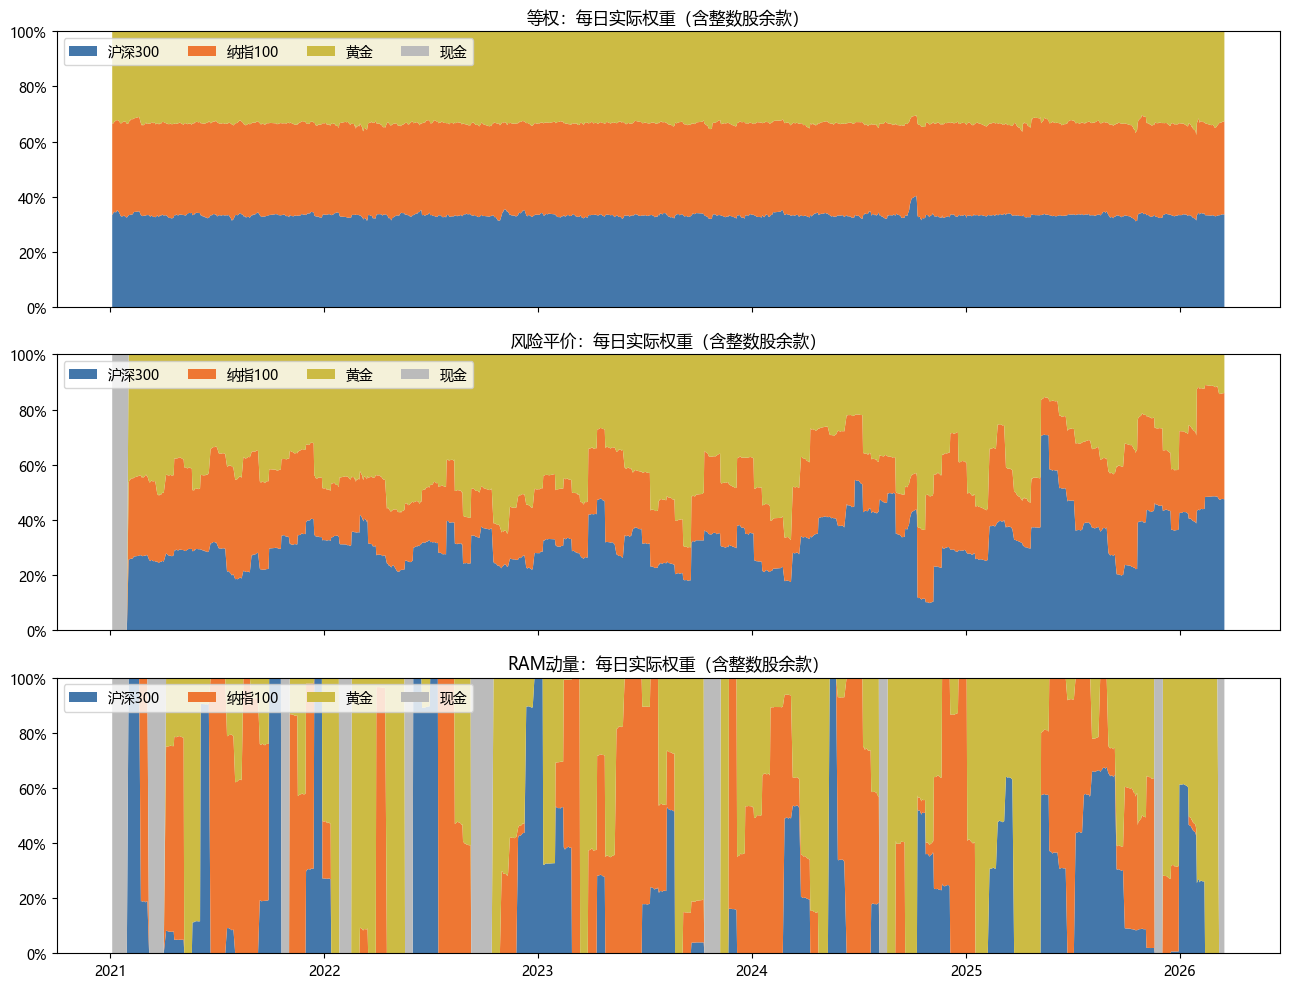

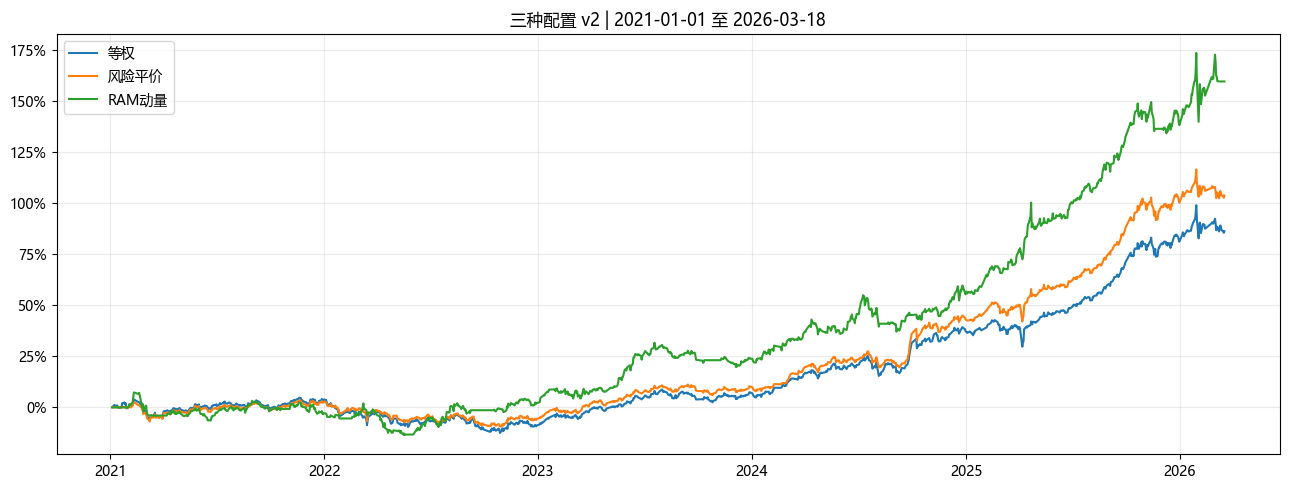

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)
for ax, (name, r) in zip(axes, results.items()):
    ax.stackplot(r["weights"].index, r["weights"].to_numpy().T,
                 labels=NAMES+["现金"], colors=["#4477AA", "#EE7733", "#CCBB44", "#BBBBBB"])
    ax.set_title(name + "：每日实际权重（含整数股余款）")
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.legend(ncol=4, loc="upper left")
fig.tight_layout()
fig.savefig(output / "weights.png", dpi=150)
plt.show()
fig, ax = plt.subplots(figsize=(13, 5))
for name, r in results.items():
    ax.plot(r["ledger"].index, r["ledger"].portfolio_value / INITIAL_CASH - 1, label=name)
ax.set_title(f"三种配置 v2 | {DATA_START} 至 {DATA_END}")
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(output / "returns.png", dpi=150)
plt.show()


[线上配置来源](https://github.com/xingwudao/xquant-learning/blob/main/q3-how-much/specs/spec-03-momentum-ranking.md)。
本实验复用学习项目的公共引擎，并非直接调用 oxq。数据缺失日采用公共券商的三者完整日期交集，删除日期已打印；这会影响10个观测日的调仓日历及年化估计。原始行情版本、缺失日处理、订单生成及统计实现可能使结果仍与线上参考数字有差异，不能将参数对齐视为数值完全复现。
